In [33]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/home/ahmed-el-kaffas/Documents/Github/QuantUS/engines/ceus
/home/ahmed-el-kaffas/Documents/Github/QuantUS/engines


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [81]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['avi', 'mp4', 'nifti']


In [82]:
scan_type = 'nifti'

scan_path = '/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/SIP/HighQualityData/UCSD/P05/V03/UCSD-P05-V03-CE2_09.34.59_mf_sip_capture_50_2_1_0_CEUS.nii'
bmode_scan_path = '/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/SIP/HighQualityData/UCSD/P05/V03/UCSD-P05-V03-CE2_09.34.59_mf_sip_capture_50_2_1_0_BMODE.nii'
scan_loader_kwargs = {
    'transpose': False,
}

In [83]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, scan_path, **scan_loader_kwargs)

## Image Preprocessing

In [ ]:
from src.image_preprocessing.options import get_im_preproc_funcs, get_required_im_preproc_kwargs

print("Available preprocessing functions:", list(get_im_preproc_funcs().keys()))

In [ ]:
preproc_func_names = ['resample'] # in order of application
required_kwargs = get_required_im_preproc_kwargs(preproc_func_names)
print("Required kwargs for preprocessing functions:", required_kwargs)

In [ ]:
preproc_kwargs = {
    'target_vox_size': (1.0, 1.0, 1.0),
    'interp': 'linear',
}

In [ ]:
from src.entrypoints import scan_preprocessing_step

image_data = scan_preprocessing_step(preproc_func_names, image_data, **preproc_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [84]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

Available segmentation loaders: ['nifti', 'load_bolus_mask']


In [85]:
seg_type = 'nifti'

seg_path = '/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/SIP/HighQualityData/UCSD/P05/V03/UCSD-P05-V03-CE2-MC_VOI.nii.gz'
seg_loader_kwargs = {}

In [86]:
from src.entrypoints import seg_loading_step

seg_data = seg_loading_step(seg_type, image_data, seg_path, scan_path, **seg_loader_kwargs)

## Segmentation Preprocessing

In [8]:
from src.seg_preprocessing.options import get_seg_preproc_funcs, get_required_seg_preproc_kwargs

print("Available preprocessing functions:", list(get_seg_preproc_funcs().keys()))

Available preprocessing functions: ['resample', 'motion_compensation_3d']


In [9]:
preproc_func_names = ['resample'] # in order of application
required_kwargs = get_required_seg_preproc_kwargs(preproc_func_names)
print("Required kwargs for preprocessing functions:", required_kwargs)

Required kwargs for preprocessing functions: ['interp', 'target_vox_size']


In [10]:
preproc_kwargs = {
    'target_vox_size': (1.0, 1.0, 1.0),
    'interp': 'nearest',
}

In [ ]:
from src.entrypoints import seg_preprocessing_step

seg_data = seg_preprocessing_step(preproc_func_names, image_data, seg_data, **preproc_kwargs)

## CEUS Quantitative Temporal Curve Analysis

In [87]:
from src.time_series_analysis.options import get_analysis_types, get_required_kwargs

all_analysis_types, all_analysis_funcs = get_analysis_types()
print("Available analysis types:", list(all_analysis_types.keys()))

Available analysis types: ['curves_paramap', 'curves']


In [88]:
analysis_type = 'curves'

print("Available analysis functions:", list(all_analysis_funcs.keys()))

Available analysis functions: ['tic', 'pyradiomics']


In [89]:
analysis_funcs = ['tic']

# Find all required kwargs for the analysis functions
analysis_funcs = analysis_funcs if len(analysis_funcs) else list(all_analysis_funcs[analysis_type].keys())
required_kwargs = get_required_kwargs(analysis_type, analysis_funcs)
print("Required kwargs for current analysis:", required_kwargs)

Required kwargs for current analysis: []


In [91]:
analysis_kwargs = {
    'curves_output_path': '/media/ahmed-el-kaffas/20TB-HDD/Farah /3DMPUS/RESULTS/UCSD-P05/ucsd-p05-v03-ce2-curves.csv',
}

In [92]:
from src.entrypoints import analysis_step

analysis_obj = analysis_step(analysis_type, image_data, seg_data, analysis_funcs, **analysis_kwargs)

Computing curves: 100%|██████████| 532/532 [00:36<00:00, 14.69it/s]


7740.070242114729


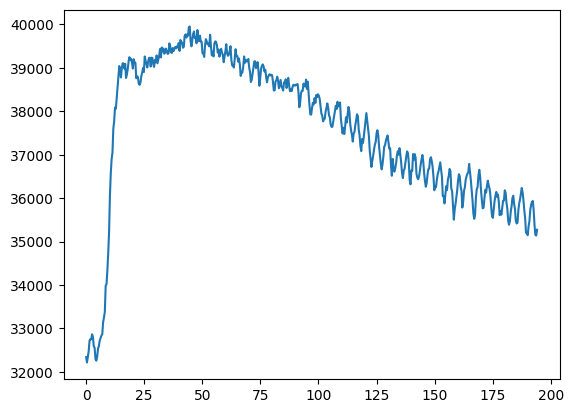

In [93]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
tic = (analysis_obj.curves[0]['TIC'])
curves_to_analyze = (np.array(tic)*3e4/255)+3e4
tmppv = np.amax(curves_to_analyze) - np.amin(curves_to_analyze)
ax.plot(analysis_obj.time_arr,curves_to_analyze, label='data=TIC')
print(tmppv)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


paths = {
    "V02-CE1": "/Volumes/Extreme Pro/TUL - FARAH/3DMPUS-HighQual-Nifti/UCSD-P01/V02/CE1/P01-V02-CE1-#5.csv",
    "V02-CE2": "/Volumes/Extreme Pro/TUL - FARAH/3DMPUS-HighQual-Nifti/UCSD-P01/V02/CE2/P01-V02-CE1-#6.csv",
}

colors = {
    "V02-CE1": "red",
    "V02-CE2": "orange"
}

plt.figure(figsize=(8,5))

for visit, path in paths.items():
    df = pd.read_csv(path)
    y_scaled = (df["TIC"].values * 3e4 / 255) + 3e4
    y_aligned = y_scaled - y_scaled.min()

    plt.plot(
        df["Time Array"],
        y_aligned,
        label=visit,
        color=colors[visit]
    )

plt.xlabel("Time (s)")
plt.ylabel("Signal Intensity")
plt.title("UCSD Patient 01 - Visit 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

paths = {
    "V02-CE1": "/Volumes/Extreme Pro/TUL - FARAH/3DMPUS-HighQual-Nifti/UCSD-P01/V03/CE1/P01-V03-CE1-#5.csv",
    "V02-CE2": "/Volumes/Extreme Pro/TUL - FARAH/3DMPUS-HighQual-Nifti/UCSD-P01/V03/CE2/P01-V03-CE2-#6.csv",
}

colors = {
    "V02-CE1": "red",
    "V02-CE2": "orange"
}

# Shifted lognormal (CEUS-style bolus model)
def shifted_lognormal(t, A, mu, sigma, t0):
    x = t - t0
    y = np.zeros_like(t, dtype=float)
    m = x > 1e-6
    y[m] = (A / (x[m] * sigma * np.sqrt(2*np.pi))) * np.exp(-((np.log(x[m]) - mu) ** 2) / (2 * sigma ** 2))
    return y

def fit_best_fit_curve(t, y):
    # Smooth so the optimizer fits the middle/envelope instead of chasing oscillations
    # window_length must be odd and < len(y)
    w = 21
    if len(y) <= w:
        w = max(5, len(y) // 2 * 2 - 1)  # fallback odd window
    y_smooth = savgol_filter(y, window_length=w, polyorder=3)

    # Baseline correct using early frames (first ~10 seconds)
    base_mask = t <= (t.min() + 10)
    baseline = np.median(y_smooth[base_mask]) if np.any(base_mask) else np.median(y_smooth[:10])
    yb = y_smooth - baseline
    yb[yb < 0] = 0

    # Guess t0 (arrival) when signal rises above small fraction of max
    thr = 0.03 * np.max(yb) if np.max(yb) > 0 else 0
    idx = np.where(yb > thr)[0]
    t0_guess = float(t[idx[0]]) if len(idx) else float(t.min())
   

    # Guess peak-based mu
    t_peak = float(t[np.argmax(yb)])
    x_peak = max(t_peak - t0_guess, 1e-3)
    mu_guess = float(np.log(x_peak))
    sigma_guess = 0.6

    # Guess A as area under curve
    A_guess = float(np.trapz(yb, t))

    p0 = [A_guess, mu_guess, sigma_guess, t0_guess]
    lower = [0, -10, 0.05, t.min() - 5]
    upper = [np.inf, 10, 5.0, t.max()]

    popt, _ = curve_fit(
        shifted_lognormal, t, yb,
        p0=p0, bounds=(lower, upper),
        maxfev=20000
    )

    y_fit = shifted_lognormal(t, *popt) + baseline
    return y_fit

plt.figure(figsize=(8,5))

for visit, path in paths.items():
    df = pd.read_csv(path)

    # --- your original scaling/alignment ---
    y_scaled = (df["TIC"].values * 3e4 / 255) + 3e4
    y_aligned = y_scaled - y_scaled.min()
    t = df["Time Array"].values.astype(float)

    # --- best fit line on the SAME y-scale you plot ---
    y_fit = fit_best_fit_curve(t, y_aligned)

    # # raw TIC
    # plt.plot(
    #     t,
    #     y_aligned,
    #     label=visit,
    #     color=colors[visit],
    #     linewidth=1.5
    # )

    # best fit (dashed)
    plt.plot(
        t,
        y_fit,
        label=f"{visit} best fit",
        color=colors[visit],
        linestyle="--",
        linewidth=3
    )

plt.xlabel("Time (s)")
plt.ylabel("Signal Intensity")
plt.title("UCSD Patient 01 — Visit 3 (Best Fit)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

paths = {
    "V02-CE1": "/Volumes/Extreme Pro/TUL - FARAH/3DMPUS-HighQual-Nifti/UCSD-P01/V02/CE1/P01-V02-CE1-#5.csv",
    "V02-CE2": "/Volumes/Extreme Pro/TUL - FARAH/3DMPUS-HighQual-Nifti/UCSD-P01/V02/CE2/P01-V02-CE1-#6.csv",
}

colors = {
    "V02-CE1": "red",
    "V02-CE2": "orange"
}

# Shifted lognormal (CEUS-style bolus model)
def shifted_lognormal(t, A, mu, sigma, t0):
    x = t - t0
    y = np.zeros_like(t, dtype=float)
    m = x > 1e-6
    y[m] = (A / (x[m] * sigma * np.sqrt(2*np.pi))) * np.exp(-((np.log(x[m]) - mu) ** 2) / (2 * sigma ** 2))
    return y

def fit_best_fit_curve(t, y):
    # Smooth so the optimizer fits the middle/envelope instead of chasing oscillations
    # window_length must be odd and < len(y)
    w = 21
    if len(y) <= w:
        w = max(5, (len(y) // 2) * 2 - 1)  # fallback odd window
    y_smooth = savgol_filter(y, window_length=w, polyorder=3)

    # Baseline correct using early frames (first ~10 seconds)
    base_mask = t <= (t.min() + 10)
    baseline = np.median(y_smooth[base_mask]) if np.any(base_mask) else np.median(y_smooth[:10])
    yb = y_smooth - baseline
    yb[yb < 0] = 0

    # Guess t0 (arrival) when signal rises above small fraction of max
    thr = 0.03 * np.max(yb) if np.max(yb) > 0 else 0
    idx = np.where(yb > thr)[0]
    t0_guess = float(t[idx[0]]) if len(idx) else float(t.min())

    # Guess peak-based mu
    t_peak = float(t[np.argmax(yb)])
    x_peak = max(t_peak - t0_guess, 1e-3)
    mu_guess = float(np.log(x_peak))
    sigma_guess = 0.6

    # Guess A as area under curve
    A_guess = float(np.trapz(yb, t))

    p0 = [A_guess, mu_guess, sigma_guess, t0_guess]
    lower = [0, -10, 0.05, t.min() - 5]
    upper = [np.inf, 10, 5.0, t.max()]

    popt, _ = curve_fit(
        shifted_lognormal, t, yb,
        p0=p0, bounds=(lower, upper),
        maxfev=20000
    )

    y_fit = shifted_lognormal(t, *popt) + baseline
    return y_fit, popt, baseline, y_smooth

plt.figure(figsize=(8, 5))

for visit, path in paths.items():
    df = pd.read_csv(path)

    # --- your original scaling/alignment ---
    y_scaled = (df["TIC"].values * 3e4 / 255) + 3e4
    y_aligned = y_scaled - y_scaled.min()
    t = df["Time Array"].values.astype(float)

    # --- fit on the SAME y-scale you plot ---
    y_fit, popt, baseline, y_smooth = fit_best_fit_curve(t, y_aligned)
    A, mu, sigma, t0 = popt

    # Print the fitted model parameters + formula
    print(f"\n{visit} shifted lognormal fit parameters:")
    print(f"  baseline = {baseline:.6g}")
    print(f"  A = {A:.6g}")
    print(f"  mu = {mu:.6g}")
    print(f"  sigma = {sigma:.6g}")
    print(f"  t0 = {t0:.6g}")
    print("  Model: y(t)=baseline + (A/((t-t0)*sigma*sqrt(2π))) * exp(-((ln(t-t0)-mu)^2)/(2*sigma^2)),  t>t0")

    # Plot raw aligned TIC (optional - uncomment if you want it shown)
    # plt.plot(t, y_aligned, label=f"{visit} raw", color=colors[visit], linewidth=1.5, alpha=0.6)

    # Plot best fit (dashed)
    plt.plot(
        t,
        y_fit,
        label=f"{visit} best fit",
        color=colors[visit],
        linestyle="--",
        linewidth=3
    )

plt.xlabel("Time (s)")
plt.ylabel("Signal Intensity")
plt.title("UCSD Patient 01 — Visit 2 (Best Fit)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [94]:
from src.curve_quantification.options import get_quantification_funcs

quantification_funcs = get_quantification_funcs()
print("Available quantification functions:", quantification_funcs.keys())

Available quantification functions: dict_keys(['lognormal_fit_full', 'dte', 'wash_rates', 'first_order_full', 'auc_no_fit', 'cmus_firstorder', 'first_order_select', 'lognormal_fit_select'])


In [95]:
function_names = ['dte', 'lognormal_fit_full'] # Empty list will use all functions

#update
output_path = '/media/ahmed-el-kaffas/20TB-HDD/Farah /3DMPUS/RESULTS/UCSD-P05/ucsd-p05-v03-ce2-quant.csv'

curve_quantifications_kwargs = {
    'curves_to_fit': ['TIC'],   # list of curve names (strings)
    'n_frames_to_analyze': 250,
    'tic_name': 'TIC'
}
print("kwargs being passed:", curve_quantifications_kwargs)

kwargs being passed: {'curves_to_fit': ['TIC'], 'n_frames_to_analyze': 250, 'tic_name': 'TIC'}


In [96]:
from src.entrypoints import curve_quantification_step

curve_quant = curve_quantification_step(analysis_obj, function_names, output_path, **curve_quantifications_kwargs)

In [97]:
import numpy as np

print(np.sum(seg_data.seg_mask))
print(np.prod(image_data.pixdim))

76274
0.07239814


In [98]:
mask = seg_data.seg_mask

voxel_vol = float(np.prod(image_data.pixdim))  # mm^3
voi_vol = np.sum(mask) * voxel_vol
print(voi_vol)

5522.095808655024


In [29]:
import numpy as np

pix = image_data.pixel_data
msk = seg_data.seg_mask

print('pixel data shape:', pix.shape, "dtype:", pix.dtype)
print('mask shape:', msk.shape, "dtype:", msk.dtype)
print("pixel data size (GB):", pix.nbytes/1e9)
print("mask size (GB):", msk.nbytes/1e9)

pixel data shape: (360, 266, 268, 450) dtype: uint8
mask shape: (360, 266, 268) dtype: uint8
pixel data size (GB): 11.548656
mask size (GB): 0.02566368


In [30]:
import numpy as np

pix = image_data.pixel_data
msk3d = seg_data.seg_mask.astype(bool)

areas_z = msk3d.sum(axis=(0, 1))
z_idx = int(np.argmax(areas_z))
print(f"z_idx = {z_idx} (max area = {int(areas_z[z_idx])})")

ix, iy, iz = np.where(msk3d)

roi_means = np.empty(pix.shape[3], dtype=np.float64)
for t in range(pix.shape[3]):
    roi_means[t] = pix[ix, iy, iz, t].mean()

t_idx = int(np.argmax(roi_means))
print(f"t_idx = {t_idx} (peak mean over 3D ROI = {roi_means[t_idx]})")

img2d = pix[:, :, z_idx, t_idx]
mask2d = msk3d[:, :, z_idx]

print("img2d:", img2d.shape, img2d.dtype)
print("mask2d:", mask2d.shape, mask2d.dtype)
print("ROI mean on extracted slice:", img2d[mask2d].mean())

z_idx = 119 (max area = 7546)
t_idx = 47 (peak mean over 3D ROI = 131.39335200107925)
img2d: (360, 266) uint8
mask2d: (360, 266) bool
ROI mean on extracted slice: 130.11926848661543


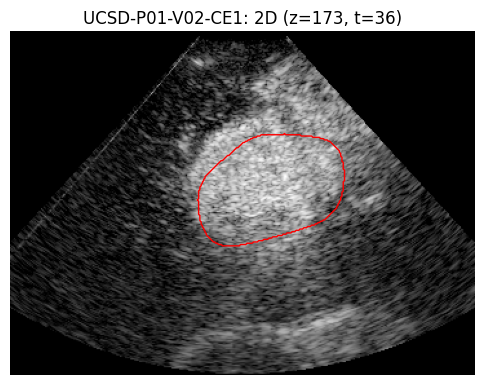

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(img2d.T, cmap="gray")
plt.contour(mask2d.T, colors="red", linewidths=1)
plt.title("UCSD-P01-V02-CE1: 2D (z=173, t=36)")
plt.axis("off")
plt.show()

In [ ]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_erosion
import imageio
from PIL import Image
import io
from tqdm import tqdm
from src.entrypoints import scan_loading_step
#scan_path = bmode_scan_path
image_data = scan_loading_step(scan_type, scan_path, **scan_loader_kwargs)



def get_mask_boundary(mask_slice):
    """Extract boundary of a binary mask using erosion."""
    if mask_slice.max() == 0:
        return np.zeros_like(mask_slice, dtype=bool)
    eroded = binary_erosion(mask_slice)
    boundary = mask_slice.astype(bool) & ~eroded
    return boundary

def get_voi_center(mask_3d):
    """Calculate the center of a 3D VOI mask."""
    coords = np.where(mask_3d > 0)
    if len(coords[0]) == 0:
        return None, None, None
    lateral_center = int(np.mean(coords[0]))
    depth_center = int(np.mean(coords[1]))
    elevation_center = int(np.mean(coords[2]))
    return lateral_center, depth_center, elevation_center

#print(f"Image shape: {image_data.pixel_data.shape}")
# print(f"Mask shape: {seg_data.seg_mask.shape}")

# Define slice positions
lateral_slice = int(image_data.pixel_data.shape[0]/2)
depth_slice = int(image_data.pixel_data.shape[0]/2)
elevation_slice = int(image_data.pixel_data.shape[1]/2)

# Frame range
num_frames = image_data.pixel_data.shape[3]
start_frame = 119
end_frame = 120
print(f"Visualizing frames {start_frame} to {end_frame}")
print("Starting animation...\n")

MC_flag = True  # Set to True to visualize motion compensated mask

# List to store frames
frames = []

# Loop through frames
for frame in tqdm(range(start_frame, end_frame), desc="Creating GIF frames"):
    # Clear previous output and display current frame
    clear_output(wait=True)

    if MC_flag:
        mask = seg_data.motion_compensation.apply_to_mask(seg_data.seg_mask, frame, 0)
    else:
        mask = seg_data.seg_mask
        print(mask.shape)

    # Calculate VOI center for this specific frame
    lateral_slice, depth_slice, elevation_slice = get_voi_center(mask)

    if lateral_slice is None:
        print(f"Warning: No VOI found in frame {frame}, skipping...")
        continue

    # Create figure for this frame
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # === AXIAL VIEW ===
    Volume_data = image_data.pixel_data[:, :, :, frame]

    # clahe_image = enhance_image(Volume_data, method='clahe', clip_limit=1.0)
    # final_image = enhance_image(clahe_image, method='gamma', gamma=1.2)
    # CEUS_image = denoise_ceus_wavelet(final_image)

    CEUS_image = Volume_data

    axial_img = np.transpose(CEUS_image[:, :, elevation_slice])
    axial_mask = np.transpose(mask[:, :, elevation_slice])
    axial_boundary = get_mask_boundary(axial_mask)

    axes[0].imshow(axial_img, cmap='gray')
    axes[0].contour(axial_boundary, colors='red', linewidths=2)
    axes[0].set_title(f'Axial (Z={elevation_slice})')
    axes[0].set_xlabel('Lateral (X)')
    axes[0].set_ylabel('Depth (Y)')

    # === CORONAL VIEW ===
    coronal_img = CEUS_image[:, depth_slice, :]
    coronal_mask = mask[:, depth_slice, :]
    coronal_boundary = get_mask_boundary(coronal_mask)

    axes[1].imshow(coronal_img, cmap='gray')
    axes[1].contour(coronal_boundary, colors='red', linewidths=2)
    axes[1].set_title(f'Coronal (Y={depth_slice})')
    axes[1].set_xlabel('Lateral (X)')
    axes[1].set_ylabel('Elevation (Z)')

    # === SAGITTAL VIEW ===
    sagittal_img = CEUS_image[lateral_slice, :, :]
    sagittal_mask = mask[lateral_slice, :, :]

    print(sagittal_mask.shape)

    sagittal_boundary = get_mask_boundary(sagittal_mask)

    print(sagittal_boundary.shape)

    axes[2].imshow(sagittal_img, cmap='gray')
    axes[2].contour(sagittal_boundary, colors='red', linewidths=2)
    axes[2].set_title(f'Sagittal (X={lateral_slice})')
    axes[2].set_xlabel('Depth (Y)')
    axes[2].set_ylabel('Elevation (Z)')

    # Add overall frame counter
    fig.suptitle(f'UCSD-P01-V02 Bolus #1', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

     # Convert figure to image array (COMPATIBLE METHOD)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)

    img = Image.open(buf).convert('RGB')
    frames.append(np.array(img))

    buf.close()

    # Print progress
    print(f"Frame {frame}/{end_frame-1}")

    plt.figure()

plt.plot(frame)
plt.xlabel("Frame")
plt.ylabel("Seconds per frame")
plt.title("Processing time per frame")
plt.show()

get_mask_boundary(mask)

    # Close figure to save memory
   # plt.close(fig)
